In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import nltk

from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

from wordcloud import WordCloud

import warnings
warnings.filterwarnings('ignore')

In [2]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to C:\Users\Puneeth
[nltk_data]     Ram\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [3]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to C:\Users\Puneeth
[nltk_data]     Ram\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [4]:
df = pd.read_csv(
    "dataset/twitter_training.csv",
    header=None
)

df.head()

,0,1,2,3
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [5]:
df.columns = [
    'id',
    'entity',
    'sentiment',
    'tweet'
]

df.head()

,id,entity,sentiment,tweet
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [6]:
df.columns = [
    'id',
    'entity',
    'sentiment',
    'tweet'
]

df.head()

,id,entity,sentiment,tweet
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [7]:
df.isnull().sum()

id             0
entity         0
sentiment      0
tweet        686
dtype: int64

In [8]:
df.dropna(inplace=True)

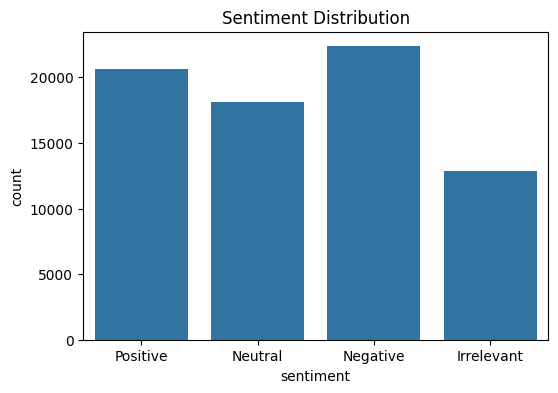

In [9]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='sentiment',
    data=df
)

plt.title("Sentiment Distribution")

plt.show()

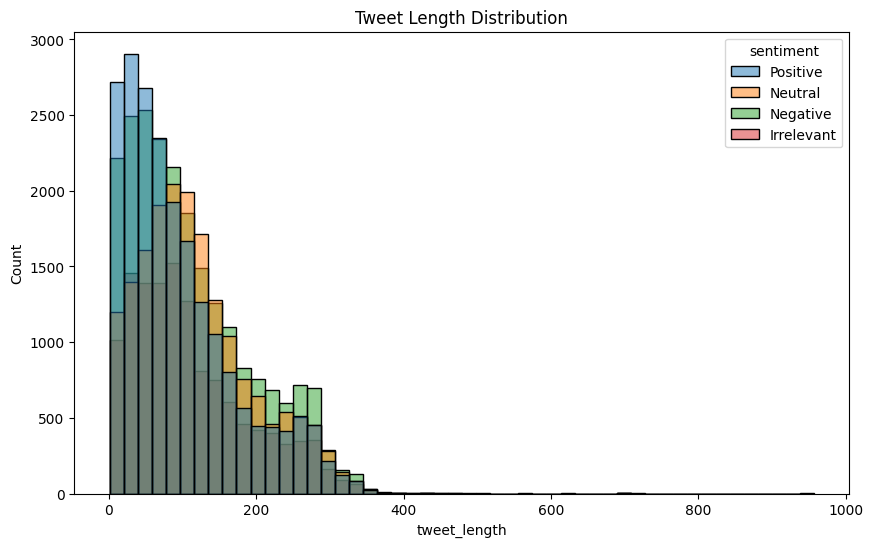

In [10]:
df['tweet_length'] = df['tweet'].apply(len)

plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x='tweet_length',
    hue='sentiment',
    bins=50
)

plt.title("Tweet Length Distribution")

plt.show()

In [11]:
ps = PorterStemmer()

In [12]:
def preprocess_text(text):

    text = re.sub('[^a-zA-Z]', ' ', text)

    text = text.lower()

    words = text.split()

    words = [
        ps.stem(word)
        for word in words
        if not word in stopwords.words('english')
    ]

    return ' '.join(words)

In [13]:
df['clean_tweet'] = df['tweet'].apply(preprocess_text)

df.head()

,id,entity,sentiment,tweet,tweet_length,clean_tweet
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...,53,im get borderland murder
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...,51,come border kill
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...,50,im get borderland kill
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...,51,im come borderland murder
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...,57,im get borderland murder


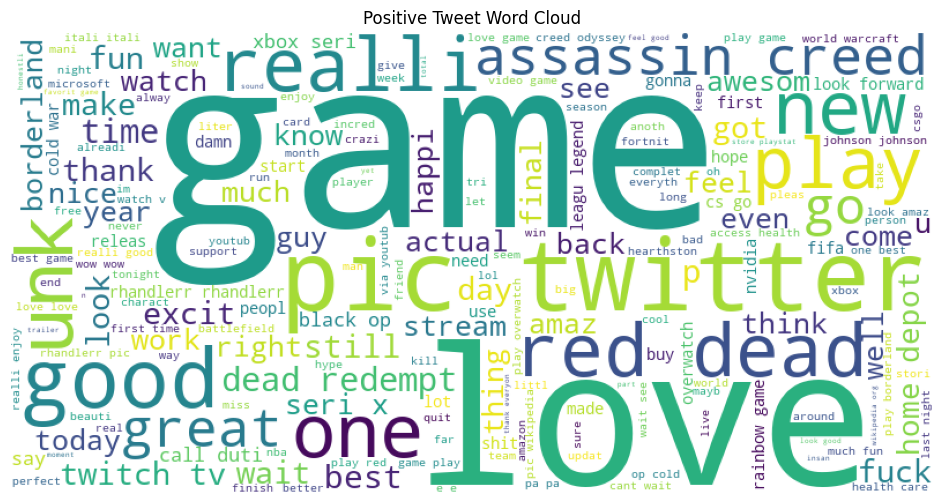

In [14]:
positive_words = ' '.join(
    list(
        df[df['sentiment']=='Positive']['clean_tweet']
    )
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(positive_words)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis('off')

plt.title("Positive Tweet Word Cloud")

plt.show()

In [15]:
df['sentiment_num'] = df['sentiment'].map({
    'Negative':0,
    'Positive':1
})

In [16]:
X = df['clean_tweet']

y = df['sentiment_num']

In [25]:
Twitter_data.isnull().sum()

NameError: name 'Twitter_data' is not defined

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

In [23]:
vectorizer = TfidfVectorizer(
    max_features=5000
)

X_train_tfidf = vectorizer.fit_transform(X_train)

X_test_tfidf = vectorizer.transform(X_test)

In [24]:
model = LogisticRegression()

model.fit(
    X_train_tfidf,
    
    y_train
)

print("Model Training Complete")

ValueError: Input y contains NaN.

In [ ]:
y_pred = model.predict(X_test_tfidf)

y_pred[:10]

In [ ]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred
)

cm

In [ ]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

In [ ]:
tweet = input("Enter Tweet: ")

cleaned = preprocess_text(tweet)

vector = vectorizer.transform([cleaned])

prediction = model.predict(vector)

if prediction[0] == 1:
    print("\nPositive Sentiment")
else:
    print("\nNegative Sentiment")